# 1D Cosine Potential and Band-Gap Opening

In the previous notebook, the particle was free. The Hamiltonian contained only the kinetic-energy operator,

$$
H(k)
=
-\frac{\hbar^2}{2m}L(k)
$$

where $L(k)$ is the Bloch finite-difference Laplacian.

That problem produced folded free-particle branches,

$$
E_\ell(k)
=
\frac{\hbar^2}{2m}
\left(k+\frac{2\pi \ell}{a}\right)^2
$$

but those branches were not material bands yet. They were the free-particle parabola viewed in a periodic representation.

Now we add a periodic potential,

$$
V(x+a)=V(x)
$$

The simplest useful choice is a cosine potential,

$$
V(x)
=
V_0\cos\left(\frac{2\pi x}{a}\right)
$$

where $a$ is the unit-cell length and $V_0$ controls the strength of the periodic potential.

The Bloch Hamiltonian becomes

$$
H(k)
=
-\frac{\hbar^2}{2m}L(k)
+
V
$$

where $V$ is a diagonal matrix in the real-space grid representation.

This is now a real band-structure problem. The potential is periodic, so it can scatter a state with wave vector $q$ into states whose wave vectors differ by reciprocal lattice vectors,

$$
q'
=
q+G
$$

where

$$
G
=
\frac{2\pi \ell}{a}
$$

For the cosine potential,

$$
V(x)
=
V_0\cos\left(\frac{2\pi x}{a}\right)
$$

the only nonzero Fourier components are at

$$
G=\pm\frac{2\pi}{a}
$$

so the potential directly couples wave components separated by $\pm 2\pi/a$.

At the Brillouin-zone boundary, two folded free-particle branches become degenerate. The periodic potential couples those degenerate states and splits their energies. This splitting is the band gap.

In [3]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt

# Physical constants
hbar = 1.055e-34   # [J s]
m_e  = 9.109e-31   # [kg]
eV   = 1.602e-19   # [J]


def build_bloch_laplacian_1d(
    N: int,
    dx: float,
    k: float,
) -> sp.csr_matrix:
    """
    Construct the 1D finite-difference Laplacian on one cell
    with Bloch boundary conditions.

    The Bloch condition is

        psi(x + a) = exp(i k a) psi(x)

    where

        a = N dx
    """

    a = N * dx

    main = -2.0 * np.ones(N)
    off = np.ones(N - 1)

    L = sp.diags(
        diagonals=[off, main, off],
        offsets=[-1, 0, 1],
        format="lil",
        dtype=complex,
    )

    L[0, -1] = np.exp(-1j * k * a)
    L[-1, 0] = np.exp(1j * k * a)

    return L.tocsr() / dx**2


def build_cosine_potential_1d(
    N: int,
    dx: float,
    V0_eV: float,
) -> sp.csr_matrix:
    """
    Construct the real-space diagonal potential

        V(x) = V0 cos(2 pi x / a)

    where V0 is supplied in eV.
    """

    a = N * dx
    x = np.arange(N) * dx

    V = V0_eV * eV * np.cos(
        2.0 * np.pi * x / a
    )

    return sp.diags(
        V,
        offsets=0,
        format="csr",
        dtype=complex,
    )


def build_bloch_hamiltonian_1d_cosine(
    N: int,
    dx: float,
    k: float,
    V0_eV: float,
    mass: float = m_e,
    hbar: float = hbar,
) -> sp.csr_matrix:
    """
    Construct the 1D Bloch Hamiltonian

        H(k) = T(k) + V

    with

        T(k) = -(hbar^2 / 2m) L(k)

    and

        V(x) = V0 cos(2 pi x / a)
    """

    L_k = build_bloch_laplacian_1d(
        N=N,
        dx=dx,
        k=k,
    )

    T_k = -(hbar**2 / (2.0 * mass)) * L_k

    V = build_cosine_potential_1d(
        N=N,
        dx=dx,
        V0_eV=V0_eV,
    )

    return T_k + V

## Computing the Cosine-Potential Bands

For the free-particle notebook, it was better to label curves by the reciprocal-lattice branch index $\ell$.

That changes here.

Once the cosine potential is added, the free-particle branches are no longer independent. The periodic potential mixes them. Therefore, the eigenvalues of $H(k)$ are now the useful band labels.

For each $k$, we solve

$$
H(k)\psi_{n,k}
=
E_n(k)\psi_{n,k}
$$

and sort the eigenvalues in ascending energy,

$$
E_1(k) \leq E_2(k) \leq E_3(k) \leq \cdots
$$

This sorted spectrum is now physically meaningful because the potential has turned the folded free-particle branches into interacting bands.

In [4]:
def calculate_cosine_bands(
    k_vals: np.ndarray,
    N_bands: int,
    N: int,
    dx: float,
    V0_eV: float,
    mass: float = m_e,
    hbar: float = hbar,
) -> np.ndarray:
    """
    Compute the lowest N_bands eigenvalues of the cosine-potential
    Bloch Hamiltonian for each k.
    """

    E_k = []

    for k in k_vals:
        H_k = build_bloch_hamiltonian_1d_cosine(
            N=N,
            dx=dx,
            k=k,
            V0_eV=V0_eV,
            mass=mass,
            hbar=hbar,
        )

        eigvals = np.linalg.eigvalsh(H_k.toarray())
        E_k.append(eigvals[:N_bands])

    return np.array(E_k)


def folded_free_particle_energy_fd(
    k_vals: np.ndarray,
    ell_vals: np.ndarray,
    a: float,
    dx: float,
    mass: float = m_e,
    hbar: float = hbar,
) -> np.ndarray:
    """
    Finite-difference folded free-particle energies:

        E_l(k) = (hbar^2 / 2m) (4 / dx^2) sin^2(q dx / 2)

    where

        q = k + G_l
    """

    E = []

    for ell in ell_vals:
        G = 2.0 * np.pi * ell / a
        q = k_vals + G

        E_ell = (
            hbar**2
            / (2.0 * mass)
            * (4.0 / dx**2)
            * np.sin(0.5 * q * dx)**2
        )

        E.append(E_ell)

    return np.array(E).T

## Plotting the Bands

The dashed curves below are the folded free-particle branches. The solid curves are the eigenvalues of the cosine-potential Hamiltonian.

The point of this plot is to show what the potential does to the free-particle folding picture. Away from degeneracies, the cosine-potential bands mostly follow the free-particle branches. Near degeneracies, the potential mixes the branches and opens gaps.

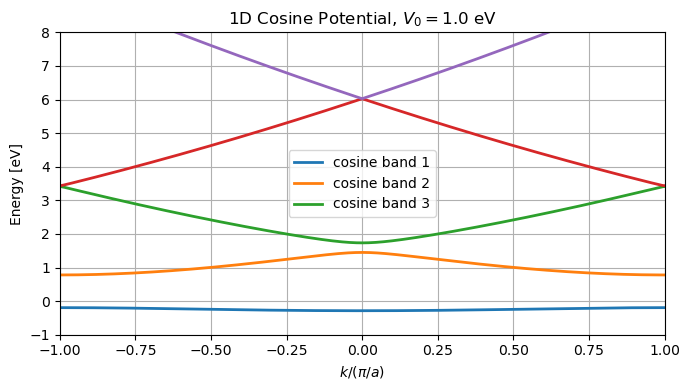

In [6]:
# Parameters

N_uc = 64
L_uc = 1e-9
dx = L_uc / N_uc
a = L_uc

N_bands = 5
V0_eV = 1.0

k_vals = np.linspace(
    -np.pi / a,
     np.pi / a,
    500,
)

k_vals_pi = k_vals * a / np.pi

ell_vals = np.array([-2, -1, 0, 1, 2])


# Free finite-difference folded branches

Ek_free_fd_eV = folded_free_particle_energy_fd(
    k_vals=k_vals,
    ell_vals=ell_vals,
    a=a,
    dx=dx,
) / eV


# Cosine-potential bands

Ek_cos_eV = calculate_cosine_bands(
    k_vals=k_vals,
    N_bands=N_bands,
    N=N_uc,
    dx=dx,
    V0_eV=V0_eV,
) / eV


# Plot

plt.figure(figsize=(7, 4))

if False:
  for j, ell in enumerate(ell_vals):
      plt.plot(
          k_vals_pi,
          Ek_free_fd_eV[:, j],
          linestyle="--",
          linewidth=1,
          alpha=0.6,
          label=rf"free $\ell={ell}$" if ell in [-1, 0, 1] else None,
      )

for n in range(N_bands):
    plt.plot(
        k_vals_pi,
        Ek_cos_eV[:, n],
        linewidth=2,
        label=f"cosine band {n + 1}" if n < 3 else None,
    )

plt.xlim([-1, 1])
plt.ylim([-1, 8])
plt.xlabel(r"$k/(\pi/a)$")
plt.ylabel("Energy [eV]")
plt.title(rf"1D Cosine Potential, $V_0={V0_eV}$ eV")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## The First Band Gap

The first band gap opens at the Brillouin-zone boundary,

$$
k=\pm\frac{\pi}{a}
$$

At this point, the free-particle branches with wave vectors related by a reciprocal lattice vector become degenerate. The cosine potential couples those branches and splits the degeneracy.

For

$$
V(x)
=
V_0\cos\left(\frac{2\pi x}{a}\right)
$$

the Fourier coefficients are

$$
V_{\pm 1}
=
\frac{V_0}{2}
$$

In [7]:
def estimate_direct_gap_at_k(
    Ek_eV: np.ndarray,
    k_vals: np.ndarray,
    k_target: float,
    lower_band: int,
    upper_band: int,
):
    """
    Estimate a direct gap between two sorted bands at a target k.
    """

    idx = np.argmin(np.abs(k_vals - k_target))

    gap = Ek_eV[idx, upper_band] - Ek_eV[idx, lower_band]

    return gap, idx


gap_right_eV, idx_right = estimate_direct_gap_at_k(
    Ek_eV=Ek_cos_eV,
    k_vals=k_vals,
    k_target=np.pi / a,
    lower_band=0,
    upper_band=1,
)

gap_left_eV, idx_left = estimate_direct_gap_at_k(
    Ek_eV=Ek_cos_eV,
    k_vals=k_vals,
    k_target=-np.pi / a,
    lower_band=0,
    upper_band=1,
)

print("Right zone boundary")
print(f"k/(pi/a) = {k_vals_pi[idx_right]:.6f}")
print(f"E1 = {Ek_cos_eV[idx_right, 0]:.6f} eV")
print(f"E2 = {Ek_cos_eV[idx_right, 1]:.6f} eV")
print(f"gap = {gap_right_eV:.6f} eV")

print()

print("Left zone boundary")
print(f"k/(pi/a) = {k_vals_pi[idx_left]:.6f}")
print(f"E1 = {Ek_cos_eV[idx_left, 0]:.6f} eV")
print(f"E2 = {Ek_cos_eV[idx_left, 1]:.6f} eV")
print(f"gap = {gap_left_eV:.6f} eV")

Right zone boundary
k/(pi/a) = 1.000000
E1 = -0.194118 eV
E2 = 0.779158 eV
gap = 0.973276 eV

Left zone boundary
k/(pi/a) = -1.000000
E1 = -0.194118 eV
E2 = 0.779158 eV
gap = 0.973276 eV


## Varying the Potential Strength

The size of the first band gap should increase as the amplitude of the cosine potential increases.

For a weak cosine potential,

$$
V(x)
=
V_0\cos\left(\frac{2\pi x}{a}\right)
$$

the first gap is approximately proportional to $V_0$,

$$
\Delta E \approx V_0
$$

This is a useful numerical check. If the gap does not scale approximately linearly with $V_0$ in the weak-potential limit, then either the plotted gap is not the first zone-boundary gap or the band indexing is being interpreted incorrectly.

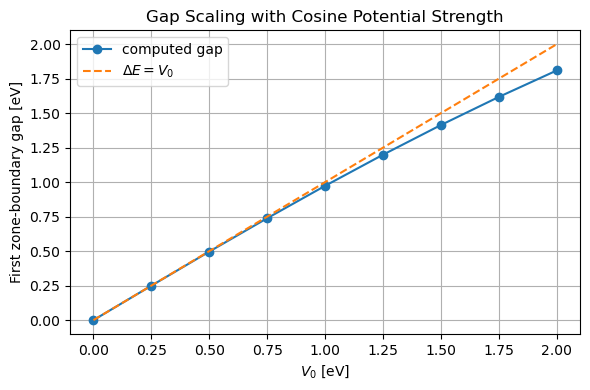

In [8]:
V0_values_eV = np.linspace(0.0, 2.0, 9)

gap_values_eV = []

for V0 in V0_values_eV:
    Ek_tmp_eV = calculate_cosine_bands(
        k_vals=k_vals,
        N_bands=2,
        N=N_uc,
        dx=dx,
        V0_eV=V0,
    ) / eV

    gap_tmp_eV, _ = estimate_direct_gap_at_k(
        Ek_eV=Ek_tmp_eV,
        k_vals=k_vals,
        k_target=np.pi / a,
        lower_band=0,
        upper_band=1,
    )

    gap_values_eV.append(gap_tmp_eV)

gap_values_eV = np.array(gap_values_eV)


plt.figure(figsize=(6, 4))

plt.plot(
    V0_values_eV,
    gap_values_eV,
    marker="o",
    label="computed gap",
)

plt.plot(
    V0_values_eV,
    V0_values_eV,
    linestyle="--",
    label=r"$\Delta E = V_0$",
)

plt.xlabel(r"$V_0$ [eV]")
plt.ylabel("First zone-boundary gap [eV]")
plt.title("Gap Scaling with Cosine Potential Strength")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 1D Cosine Potential: Bands and Density of States

In the free-particle notebook, the folded branches were produced only by representation. The Hamiltonian contained no potential,

$$
H(k)
=
-\frac{\hbar^2}{2m}L(k)
$$

so the branches were folded free-particle parabolas.

Now we add a periodic potential,

$$
V(x)
=
V_0\cos\left(\frac{2\pi x}{a}\right)
$$

where $a$ is the unit-cell length. The Bloch Hamiltonian becomes

$$
H(k)
=
-\frac{\hbar^2}{2m}L(k)+V
$$

The cosine potential is periodic,

$$
V(x+a)=V(x)
$$

so the Hamiltonian can still be solved independently at each Bloch wave vector $k$ in the first Brillouin zone.

For each $k$, we solve

$$
H(k)\psi_{n,k}
=
E_n(k)\psi_{n,k}
$$

The functions $E_n(k)$ are the energy bands.

The purpose of this notebook is not only to plot $E_n(k)$. The purpose is to use those bands to compute the density of states.

In [9]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt

# Physical constants
hbar = 1.055e-34   # [J s]
m_e  = 9.109e-31   # [kg]
eV   = 1.602e-19   # [J]


def build_bloch_laplacian_1d(
    N: int,
    dx: float,
    k: float,
) -> sp.csr_matrix:
    """
    Construct the 1D finite-difference Laplacian on one cell
    with Bloch boundary conditions.

    The cell length is

        a = N dx

    and the Bloch boundary condition is

        psi(x + a) = exp(i k a) psi(x)
    """

    a = N * dx

    main = -2.0 * np.ones(N)
    off = np.ones(N - 1)

    L = sp.diags(
        diagonals=[off, main, off],
        offsets=[-1, 0, 1],
        format="lil",
        dtype=complex,
    )

    L[0, -1] = np.exp(-1j * k * a)
    L[-1, 0] = np.exp(1j * k * a)

    return L.tocsr() / dx**2


def build_cosine_potential_1d(
    N: int,
    dx: float,
    V0_eV: float,
) -> sp.csr_matrix:
    """
    Construct the diagonal potential matrix

        V(x) = V0 cos(2 pi x / a)

    where V0 is supplied in eV.
    """

    a = N * dx
    x = np.arange(N) * dx

    V = V0_eV * eV * np.cos(
        2.0 * np.pi * x / a
    )

    return sp.diags(
        V,
        offsets=0,
        format="csr",
        dtype=complex,
    )


def build_bloch_hamiltonian_1d_cosine(
    N: int,
    dx: float,
    k: float,
    V0_eV: float,
    mass: float = m_e,
    hbar: float = hbar,
) -> sp.csr_matrix:
    """
    Construct the 1D Bloch Hamiltonian

        H(k) = T(k) + V

    with

        T(k) = -(hbar^2 / 2m) L(k)

    and

        V(x) = V0 cos(2 pi x / a)
    """

    L_k = build_bloch_laplacian_1d(
        N=N,
        dx=dx,
        k=k,
    )

    T_k = -(hbar**2 / (2.0 * mass)) * L_k

    V = build_cosine_potential_1d(
        N=N,
        dx=dx,
        V0_eV=V0_eV,
    )

    return T_k + V

## Computing the Bands

For the cosine potential, the free-particle branch label $\ell$ is no longer the best band label. The potential mixes folded free-particle branches, especially near degeneracies.

Therefore, for each $k$, we sort the eigenvalues,

$$
E_1(k)\leq E_2(k)\leq E_3(k)\leq \cdots
$$

and use the sorted eigenvalue index as the band index.

In [10]:
def calculate_cosine_bands(
    k_vals: np.ndarray,
    N_bands: int,
    N: int,
    dx: float,
    V0_eV: float,
    mass: float = m_e,
    hbar: float = hbar,
) -> np.ndarray:
    """
    Compute the lowest N_bands eigenvalues of the cosine-potential
    Bloch Hamiltonian for each k.

    Returns
    -------
    E_k : np.ndarray
        Array with shape (len(k_vals), N_bands), in joules.
    """

    E_k = []

    for k in k_vals:
        H_k = build_bloch_hamiltonian_1d_cosine(
            N=N,
            dx=dx,
            k=k,
            V0_eV=V0_eV,
            mass=mass,
            hbar=hbar,
        )

        eigvals = np.linalg.eigvalsh(H_k.toarray())

        E_k.append(eigvals[:N_bands])

    return np.array(E_k)


def folded_free_particle_energy_fd(
    k_vals: np.ndarray,
    ell_vals: np.ndarray,
    a: float,
    dx: float,
    mass: float = m_e,
    hbar: float = hbar,
) -> np.ndarray:
    """
    Finite-difference folded free-particle energies.

    The physical wave vector is

        q = k + G_l

    where

        G_l = 2 pi l / a

    The finite-difference kinetic energy is

        E_l(k) = (hbar^2 / 2m) (4 / dx^2) sin^2(q dx / 2)
    """

    E = []

    for ell in ell_vals:
        G = 2.0 * np.pi * ell / a
        q = k_vals + G

        E_ell = (
            hbar**2
            / (2.0 * mass)
            * (4.0 / dx**2)
            * np.sin(0.5 * q * dx)**2
        )

        E.append(E_ell)

    return np.array(E).T

In [11]:
# Parameters

N_uc = 96
L_uc = 1e-9
dx = L_uc / N_uc
a = L_uc

N_bands = 6
V0_eV = 1.0

N_k = 800

k_vals = np.linspace(
    -np.pi / a,
     np.pi / a,
    N_k,
)

k_vals_pi = k_vals * a / np.pi

ell_vals = np.array([-3, -2, -1, 0, 1, 2, 3])


# Free folded branches for reference

Ek_free_fd_eV = folded_free_particle_energy_fd(
    k_vals=k_vals,
    ell_vals=ell_vals,
    a=a,
    dx=dx,
) / eV


# Cosine-potential bands

Ek_cos_eV = calculate_cosine_bands(
    k_vals=k_vals,
    N_bands=N_bands,
    N=N_uc,
    dx=dx,
    V0_eV=V0_eV,
) / eV

## Density of States

The band structure tells us the allowed energies as functions of wave vector,

$$
E_n(k)
$$

The density of states asks a different question:

How many states are available near a given energy $E$?

For a one-dimensional system, the density of states per unit length is

$$
g(E)
=
\sum_n
\int_\mathrm{BZ}
\delta\left(E-E_n(k)\right)
\frac{dk}{2\pi}
$$

where the sum is over bands.

This formula says that each band contributes states at the energies it reaches. In one dimension, the density of states becomes large when the band becomes flat. This follows from the identity

$$
g(E)
\sim
\sum_n
\sum_{k_i:E_n(k_i)=E}
\frac{1}{\left|dE_n/dk\right|_{k_i}}
$$

where $k_i$ are the wave vectors satisfying

$$
E_n(k_i)=E
$$

Thus:

- flat band region $\Rightarrow$ small $|dE/dk|$ $\Rightarrow$ large DOS
- band gap $\Rightarrow$ no allowed $E_n(k)$ values $\Rightarrow$ zero DOS

For a first numerical implementation, we estimate $g(E)$ by histogramming the sampled energies from all computed bands.

In [12]:
def calculate_dos_histogram(
    Ek_eV: np.ndarray,
    k_vals: np.ndarray,
    n_bins: int = 300,
    energy_range: tuple[float, float] | None = None,
):
    """
    Estimate the 1D density of states from sampled bands using a histogram.

    Parameters
    ----------
    Ek_eV:
        Band energies with shape (N_k, N_bands), in eV.

    k_vals:
        Sampled k values in 1/m.

    n_bins:
        Number of energy bins.

    energy_range:
        Optional tuple (E_min, E_max) in eV.

    Returns
    -------
    E_centers:
        Energy-bin centers in eV.

    dos:
        Histogram-based DOS estimate.

    Notes
    -----
    This gives a normalized DOS-like distribution. It is best used
    first as a qualitative diagnostic.
    """

    energies = Ek_eV.ravel()

    counts, edges = np.histogram(
        energies,
        bins=n_bins,
        range=energy_range,
        density=False,
    )

    E_centers = 0.5 * (edges[:-1] + edges[1:])
    dE = edges[1] - edges[0]

    # Weight each k point by dk/(2 pi).
    # For uniform k-grid:
    dk = k_vals[1] - k_vals[0]

    dos = counts * dk / (2.0 * np.pi * dE)

    return E_centers, dos

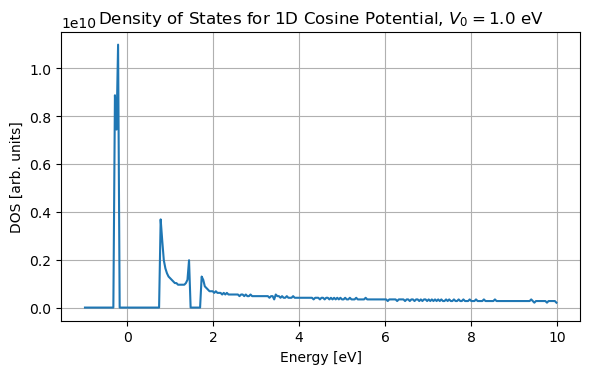

In [13]:
E_centers, dos = calculate_dos_histogram(
    Ek_eV=Ek_cos_eV,
    k_vals=k_vals,
    n_bins=300,
    energy_range=(-1.0, 10.0),
)

plt.figure(figsize=(6, 4))

plt.plot(
    E_centers,
    dos,
)

plt.xlabel("Energy [eV]")
plt.ylabel(r"DOS [arb. units]")
plt.title(rf"Density of States for 1D Cosine Potential, $V_0={V0_eV}$ eV")
plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
import matplotlib.pyplot as plt

def plot_bandstructure_and_dos(
    k_vals_pi: np.ndarray,
    Ek_eV: np.ndarray,
    E_centers: np.ndarray,
    dos: np.ndarray,
    *,
    energy_min: float | None = None,
    energy_max: float | None = None,
    title_band: str = "Band Structure",
    title_dos: str = "Density of States",
):
    """
    Plot band structure and DOS side-by-side with a shared energy axis.

    Parameters
    ----------
    k_vals_pi
        Dimensionless k values, typically k / (pi / a)

    Ek_eV
        Band energies with shape (N_k, N_bands), in eV

    E_centers
        Energy grid for DOS, in eV

    dos
        Density of states evaluated on E_centers

    energy_min, energy_max
        Optional y-axis limits in eV
    """

    fig, (ax_band, ax_dos) = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(9, 6),
        sharey=True,
        gridspec_kw={"width_ratios": [2.5, 1], "wspace": 0.05},
    )

    # --------------------------------------------------
    # Band structure
    # --------------------------------------------------
    n_bands = Ek_eV.shape[1]

    for n in range(n_bands):
        ax_band.plot(
            k_vals_pi,
            Ek_eV[:, n],
            linewidth=2,
        )

    ax_band.set_xlabel(r"$k/(\pi/a)$")
    ax_band.set_ylabel("Energy [eV]")
    ax_band.set_title(title_band)
    ax_band.set_xlim([-1, 1])
    ax_band.grid(True)

    # Optional Brillouin-zone boundary markers
    ax_band.axvline(-1, linestyle="--", linewidth=1)
    ax_band.axvline( 1, linestyle="--", linewidth=1)

    # --------------------------------------------------
    # DOS
    # --------------------------------------------------
    ax_dos.plot(
        dos,
        E_centers,
        linewidth=2,
    )

    ax_dos.set_xlabel("DOS [arb. units]")
    ax_dos.set_title(title_dos)
    ax_dos.grid(True)

    # Put DOS axis on the right
    ax_dos.yaxis.tick_right()
    ax_dos.yaxis.set_label_position("right")

    # --------------------------------------------------
    # Shared energy limits
    # --------------------------------------------------
    if energy_min is None:
        energy_min = min(np.min(Ek_eV), np.min(E_centers))

    if energy_max is None:
        energy_max = max(np.max(Ek_eV), np.max(E_centers))

    ax_band.set_ylim([energy_min, energy_max])

    plt.tight_layout()
    plt.show()

/var/folders/42/g1m9r43x2_v4bkyg4csrsn100000gn/T/ipykernel_6226/3748787782.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


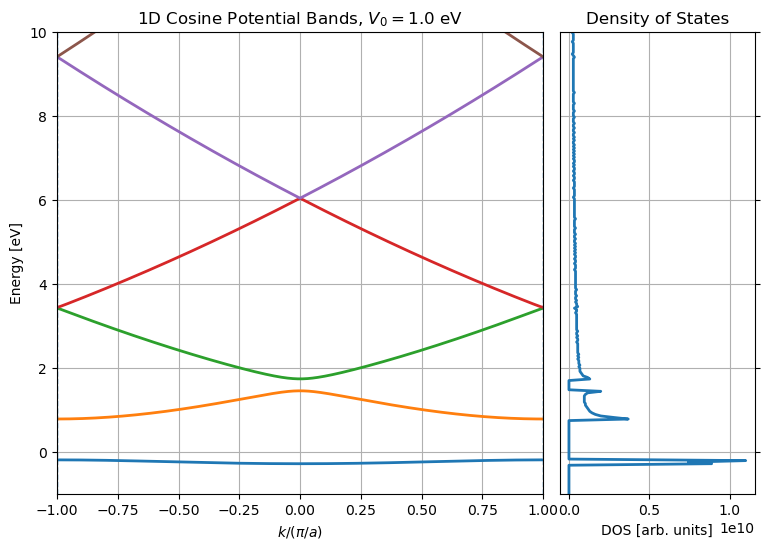

In [15]:
plot_bandstructure_and_dos(
    k_vals_pi=k_vals_pi,
    Ek_eV=Ek_cos_eV,
    E_centers=E_centers,
    dos=dos,
    energy_min=-1.0,
    energy_max=10.0,
    title_band=rf"1D Cosine Potential Bands, $V_0={V0_eV}$ eV",
    title_dos="Density of States",
)